# Tutorial 10 — From Concrete Mix Design to an End-to-End ML Pipeline

## A Case Study in Predictive Concrete Strength

Imagine you are working as an **ML engineer supporting a civil engineering team**.  
The materials team has a concrete mixture and wants to estimate its **compressive strength** before waiting for laboratory testing.

You are given the mixture proportions — cement, slag, fly ash, water, aggregates, superplasticizer — together with the **age of the concrete**. Your task is to build a machine-learning workflow that learns the relationship between these inputs and the measured compressive strength.

In this tutorial, we will approach the problem the way an ML team would approach a small real-world project:

> **Understand the data → prepare the data → build a baseline → train ML models → evaluate them → package the workflow into a reusable pipeline.**

Rather than treating the notebook as a collection of disconnected algorithms, we will build the solution step-by-step and make decisions based on what we observe from the data.

## Case Study — Predicting Concrete Compressive Strength

Concrete strength depends on several interacting factors, including the amounts of different ingredients and the age of the concrete. In practice, determining strength requires laboratory testing, which takes time and resources.

Our engineering team has historical laboratory measurements from **1,030 concrete mixtures**. Each observation contains:

- **8 input variables:** concrete ingredients and age
- **1 target variable:** measured compressive strength in MPa

Our objective is to learn a model from the historical data that can estimate the compressive strength of a **new concrete mixture**.

### The engineering question

> **Given a concrete mixture and its age, how accurately can we predict its compressive strength?**

This is a **supervised learning regression problem** because the target is a continuous numerical quantity: compressive strength (MPa).

We will compare two tree-based models:

- **Decision Tree Regression** — a single tree that learns a set of decision rules from the data.
- **Random Forest Regression** — an ensemble of many decision trees designed to produce a more robust prediction.

Finally, we will turn our chosen workflow into a **reusable ML pipeline** that can be saved and used to make predictions on new concrete mixtures.

## Your Role — From Laboratory Data to an ML System

You are not just training a model. You are responsible for turning historical engineering data into a **reproducible prediction workflow** that another engineer could use.

Throughout the tutorial, think of yourself as the ML engineer on the project:

1. **Understand** what the data represents.
2. **Check** whether the data is suitable for modeling.
3. **Define** the prediction task and evaluation strategy.
4. **Build** a simple baseline.
5. **Train and compare** Decision Tree and Random Forest models.
6. **Evaluate** performance on data the models have not seen.
7. **Package** the final workflow into a reusable ML pipeline.
8. **Use** the trained pipeline to predict the strength of a new concrete mixture.

The goal is not to find a perfect model. The goal is to understand the **end-to-end ML lifecycle** and how an engineering prediction problem can be turned into a practical ML system.

> **Engineering mindset:** Every modeling decision should have a reason. Let the data and the engineering problem guide the workflow.

In [1]:
# ============================================================
# Setup
# ============================================================
# Import the Python libraries we will use throughout the tutorial.
#
# We will keep the setup focused:
# - pandas / numpy: data manipulation
# - matplotlib / seaborn: visualization
# - scikit-learn: machine learning, model evaluation, and pipelines


# Import NumPy for numerical operations and arrays.
import numpy as np

# Import pandas for loading, inspecting, and manipulating tabular data.
import pandas as pd

# Import Matplotlib for creating plots and figures.
import matplotlib.pyplot as plt

# Import Seaborn for higher-level statistical visualizations.
import seaborn as sns

# Import the function used to split our data into training and test sets.
from sklearn.model_selection import train_test_split

# Import a Decision Tree model for regression.
from sklearn.tree import DecisionTreeRegressor

# Import a Random Forest model for regression.
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics for measuring regression performance.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import Pipeline so we can package our ML workflow into a reusable object later.
from sklearn.pipeline import Pipeline

# Import the tree module so we can visualize the trained Decision Tree later.
from sklearn import tree

# Apply a clean Seaborn style to make our plots easier to read.
sns.set_theme(style="whitegrid")

# Set a fixed random seed so that our results are reproducible.
RANDOM_STATE = 42

# Step 1 — Understand the Engineering Dataset

Before training any model, we need to understand **what our data represents**.

The dataset contains laboratory measurements of concrete mixtures. Each row represents a concrete mixture tested at a particular age, and the final column records the measured compressive strength.

The dataset contains:

- **8 quantitative input variables** describing the concrete mixture and its age
- **1 quantitative output variable**: compressive strength in MPa
- **1,030 observations**
- **No missing values**, according to the dataset documentation

An important point is that the variables are already numerical and expressed in meaningful engineering units such as **kg/m³, days, and MPa**. We therefore do not need categorical encoding for this dataset.

> **Before we make any modeling decisions, let's verify these assumptions directly from the data.**

Our first step is simply to load the dataset and inspect what we have.

In [2]:
# Define the path to our CSV dataset.
DATA_PATH = "Concrete_Data.csv"

# Read the CSV file into a pandas DataFrame.
# Each row represents one laboratory-tested concrete mixture.
concrete_df = pd.read_csv(DATA_PATH)

# Display the first five observations to confirm that the data loaded correctly.
concrete_df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
# Check the number of observations and variables in the dataset.
# We expect 1,030 rows and 9 columns based on the dataset documentation.
print("Dataset shape:", concrete_df.shape)

# Display the column names so we can see exactly how the dataset is structured.
print("\nColumn names:")
print(concrete_df.columns.tolist())

# Display the data types and number of non-missing values for each column.
# This helps us verify that the numerical measurements were read correctly.
print("\nDataset information:")
concrete_df.info()

# Count missing values in each column.
# A value of 0 means that the column contains no missing observations.
print("\nMissing values:")
print(concrete_df.isna().sum())

# Count completely duplicated rows.
# Duplicate observations can affect model training, so we check for them early.
print("\nNumber of duplicated rows:", concrete_df.duplicated().sum())

Dataset shape: (1030, 9)

Column names:
['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64


## Data Quality Check: Duplicate Records

Before building a model, we need to check whether the dataset contains duplicate observations.

Duplicate rows are not automatically errors. In an engineering dataset, repeated measurements can sometimes be legitimate experimental observations. We therefore inspect the duplicates first and decide whether they should be removed.

For this dataset, we found **25 exact duplicate rows**. Let's examine them before making any changes to the data.

In [4]:
# Count the number of rows that are exact duplicates of another row.
duplicate_count = concrete_df.duplicated().sum()

# Print the number of duplicate rows so we can confirm our data-quality finding.
print(f"Number of duplicate rows: {duplicate_count}")

# Select all rows that belong to a duplicated group.
# keep=False marks every occurrence, including the first one.
duplicates = concrete_df[concrete_df.duplicated(keep=False)]

# Sort the duplicated rows by all columns so identical observations
# appear next to each other and are easier to inspect.
duplicates = duplicates.sort_values(by=concrete_df.columns.tolist())

# Display the first 20 duplicated rows.
duplicates.head(20)

Number of duplicate rows: 25


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
801,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
809,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
106,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
111,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
129,362.6,189.0,0.0,164.9,11.6,944.7,755.8,28,71.30


### Handling Exact Duplicate Records

Our inspection shows that the dataset contains **25 exact duplicate rows**.

For example, some mixtures appear multiple times with exactly the same:

- ingredient quantities,
- concrete age, and
- measured compressive strength.

Because our goal is to predict the strength of a new mixture, keeping identical copies would give those observations disproportionate influence during training.

There is also an important modeling reason to remove them **before** creating the train/test split: otherwise, an identical observation could appear in both sets, making our test performance look better than it really is.

> **Decision:** For this tutorial, we will remove exact duplicate records and document this as part of our data-quality preprocessing.

In [5]:
# Remove rows that are exact duplicates across all columns.
# This prevents identical observations from receiving extra weight during training.
concrete_df = concrete_df.drop_duplicates()

# Reset the DataFrame index after removing rows.
# drop=True prevents the old index from being kept as a new column.
concrete_df = concrete_df.reset_index(drop=True)

# Display the new dataset shape so we can see how many observations remain.
print("Dataset shape after removing duplicates:", concrete_df.shape)

# Verify that no exact duplicate rows remain.
print("Remaining duplicate rows:", concrete_df.duplicated().sum())

Dataset shape after removing duplicates: (1005, 9)
Remaining duplicate rows: 0


## Step 2 — Understand the Variables

Before choosing a model, we need to understand what each variable represents and whether the values look reasonable.

The original dataset uses long descriptive column names, which are useful for documentation but inconvenient for analysis. We will give the variables shorter names while keeping the same measurements and units.

Our inputs are:

- `cement`
- `slag`
- `fly_ash`
- `water`
- `superplasticizer`
- `coarse_aggregate`
- `fine_aggregate`
- `age_days`

Our prediction target is:

- `strength_mpa` — measured concrete compressive strength

This is only a **column-name cleanup**. We are not changing any values.

In [6]:
# Rename the columns using concise names that are easier to work with.
# The values and units in the dataset remain unchanged.
concrete_df = concrete_df.rename(columns={
    "Cement (component 1)(kg in a m^3 mixture)": "cement",
    "Blast Furnace Slag (component 2)(kg in a m^3 mixture)": "slag",
    "Fly Ash (component 3)(kg in a m^3 mixture)": "fly_ash",
    "Water  (component 4)(kg in a m^3 mixture)": "water",
    "Superplasticizer (component 5)(kg in a m^3 mixture)": "superplasticizer",
    "Coarse Aggregate  (component 6)(kg in a m^3 mixture)": "coarse_aggregate",
    "Fine Aggregate (component 7)(kg in a m^3 mixture)": "fine_aggregate",
    "Age (day)": "age_days",
    "Concrete compressive strength(MPa, megapascals) ": "strength_mpa"
})

# Define the input variables that will be used to predict strength.
feature_columns = [
    "cement",
    "slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_aggregate",
    "fine_aggregate",
    "age_days"
]

# Define the variable we want our ML models to predict.
target_column = "strength_mpa"

# Display the cleaned column names to confirm the rename worked.
print(concrete_df.columns.tolist())

['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age_days', 'strength_mpa']


## First Look at the Measurements

Let's profile the numerical variables before building any model.

For an engineering dataset, summary statistics are a quick way to identify:

- the typical range of each measurement,
- variables with very different scales,
- unusually large or small values,
- and whether the target variable has a reasonable range.

This matters because our features are measured in very different units and magnitudes. For example, aggregate quantities are measured in hundreds of kg/m³, while the age is measured in days.

We will **not modify anything based on these statistics yet**. First, we want to understand what the data is telling us.

In [7]:
# Calculate descriptive statistics for all numerical variables.
# This gives us the count, mean, standard deviation, minimum,
# quartiles, and maximum for each column.
summary = concrete_df[feature_columns + [target_column]].describe()

# Display the summary statistics.
summary

,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,strength_mpa
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.631343,72.043483,55.536318,182.075323,6.033234,974.376816,772.688259,45.856716,35.250378
std,104.344261,86.170807,64.207969,21.339334,5.919967,77.579667,80.340435,63.734692,16.284815
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.700000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.800000
75%,349.000000,142.500000,118.300000,192.900000,10.000000,1031.000000,822.200000,56.000000,44.870000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## Target Variable: Compressive Strength

Before building a predictive model, we first inspect the variable we want to predict.

Our target is **concrete compressive strength**, measured in MPa. Understanding its distribution helps us identify its typical range, variability, and whether there are unusually low or high observations that may need further investigation.

At this stage, we are not changing the data — we are simply learning what the prediction problem looks like.

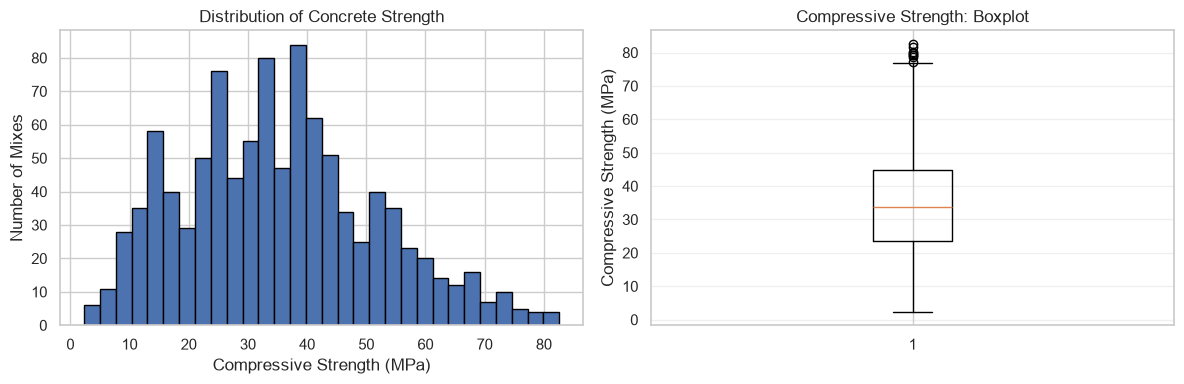

In [8]:
# Create a figure with two plots side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot a histogram to show the distribution of compressive strength.
axes[0].hist(
    concrete_df["strength_mpa"],  # Use the concrete strength values.
    bins=30,                      # Divide the values into 30 intervals.
    edgecolor="black"             # Add borders to make the bars easier to see.
)

# Add a descriptive title to the histogram.
axes[0].set_title("Distribution of Concrete Strength")

# Label the x-axis with the target variable and its unit.
axes[0].set_xlabel("Compressive Strength (MPa)")

# Label the y-axis with the number of observations.
axes[0].set_ylabel("Number of Mixes")

# Plot a boxplot to show the median, spread, and potential extreme values.
axes[1].boxplot(
    concrete_df["strength_mpa"]  # Use the same target variable.
)

# Add a descriptive title to the boxplot.
axes[1].set_title("Compressive Strength: Boxplot")

# Label the y-axis with the target variable and its unit.
axes[1].set_ylabel("Compressive Strength (MPa)")

# Add a light horizontal grid to make the boxplot easier to read.
axes[1].grid(axis="y", alpha=0.3)

# Adjust spacing between the two plots.
plt.tight_layout()

# Display the figure.
plt.show()

## Step 3 — Explore Feature–Target Relationships

Now that we understand the target, we want to see how the input variables relate to compressive strength.

A simple first diagnostic is **correlation**. It measures the strength and direction of a linear relationship between two numerical variables.

This is not a modeling step, and correlation does not tell us whether a variable *causes* strength to increase or decrease. It simply gives us a useful first look at which measurements may contain predictive information.

We will use this as a guide for further exploration — not as a reason to automatically remove or keep features.

In [9]:
# Calculate the Pearson correlation between every numerical variable.
# The resulting matrix shows how strongly the variables move together.
correlation_matrix = concrete_df[feature_columns + [target_column]].corr()

# Extract only the correlations with our prediction target.
# Sorting them makes the strongest relationships easier to identify.
target_correlations = (
    correlation_matrix[target_column]
    .sort_values(ascending=False)
)

# Display the correlations with compressive strength.
target_correlations

strength_mpa        1.000000
cement              0.488283
superplasticizer    0.344209
age_days            0.337367
slag                0.103374
fly_ash            -0.080648
coarse_aggregate   -0.144717
fine_aggregate     -0.186448
water              -0.269624
Name: strength_mpa, dtype: float64

## Looking for Relationships Between Variables

The target correlations give us a first indication of which inputs may be useful.

However, the concrete ingredients are part of the same mixture, so some input variables may also be strongly related to one another. This is important to understand before modeling.

We will visualize the full correlation matrix to look for:

- relationships between features,
- possible groups of highly related variables,
- and the overall relationship between the inputs and compressive strength.

Remember that correlation measures **linear association**. A weak correlation does not necessarily mean that a variable is unimportant for a machine-learning model.

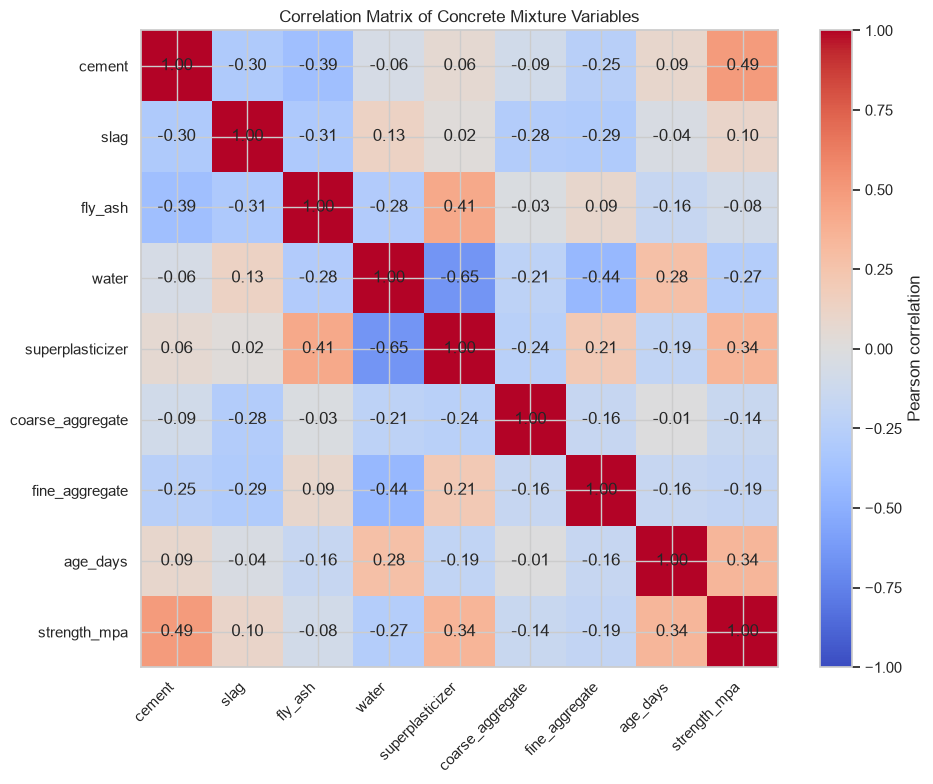

In [10]:
# Import NumPy so we can control the values displayed on the heatmap.
import numpy as np

# Calculate the correlation matrix for all model variables.
correlation_matrix = concrete_df[feature_columns + [target_column]].corr()

# Create a figure large enough to display all variable names clearly.
fig, ax = plt.subplots(figsize=(10, 8))

# Display the correlation matrix as a color-coded image.
image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Add a color bar to show how the colors correspond to correlation values.
fig.colorbar(image, ax=ax, label="Pearson correlation")

# Place the variable names along the horizontal axis.
ax.set_xticks(np.arange(len(correlation_matrix.columns)))

# Place the variable names along the vertical axis.
ax.set_yticks(np.arange(len(correlation_matrix.columns)))

# Use the actual column names as tick labels.
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")

# Use the actual column names as tick labels.
ax.set_yticklabels(correlation_matrix.columns)

# Write the numerical correlation value inside every cell.
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

# Add a descriptive title to the heatmap.
ax.set_title("Correlation Matrix of Concrete Mixture Variables")

# Adjust the layout so labels are not cut off.
plt.tight_layout()

# Display the correlation heatmap.
plt.show()

## Step 4 — Define the ML Problem and Create a Holdout Set

We are now moving from exploratory analysis into the **machine-learning workflow**.

Our business/engineering question is:

> **Given a concrete mixture and its age, can we predict its compressive strength?**

This is a **supervised regression problem** because:

- we have input measurements describing each concrete mixture,
- we have a known numerical target (`strength_mpa`),
- and we want to predict that numerical target for new observations.

Before training any model, we create a **holdout test set**.

The test set will remain untouched during model development. This gives us a more honest estimate of how the final model may perform on new concrete mixtures.

We will use:

- **80%** of the data for training,
- **20%** for final testing.

All of our input variables are already numerical, so **one-hot encoding is not required**. One-hot encoding is useful when categorical variables such as `concrete_type = ["normal", "high-performance"]` need to be converted into numerical features. That situation does not occur here.

We also do not need feature scaling specifically for the tree-based models we will use later.

In [11]:
# Import the function used to create training and test sets.
from sklearn.model_selection import train_test_split

# Select the input variables that the model will use for prediction.
X = concrete_df[feature_columns]

# Select the measured compressive strength that the model will learn to predict.
y = concrete_df[target_column]

# Split the observations into training and holdout test sets.
# 80% of the observations are used for training.
# 20% are kept completely separate for final evaluation.
# random_state makes the split reproducible for everyone running the tutorial.
X_train, X_test, y_train, y_test = train_test_split(
    X,                      # Input features.
    y,                      # Regression target.
    test_size=0.20,         # Reserve 20% of the data for final testing.
    random_state=42         # Use a fixed seed so the split is reproducible.
)

# Display the number of observations and features in each split.
print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

# Display the corresponding target sizes.
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (804, 8)
Test features: (201, 8)
Training target: (804,)
Test target: (201,)


## Step 5 — Establish a Baseline

Before training a machine-learning model, we need a simple reference point.

A baseline answers a basic question:

> **How well could we predict concrete strength without learning a relationship between the mixture variables and strength?**

For this tutorial, we will use the **mean strength of the training data** as our baseline prediction.

For every concrete mixture in the test set, the baseline will simply predict the same value: the average strength observed in the training set.

This gives us a benchmark that our ML models should improve upon.

Importantly, we calculate the mean using **training data only**. The test set remains untouched until final evaluation.

In [12]:
# Calculate the average compressive strength using the training data only.
# We do not use y_test because the test set must remain unseen during development.
baseline_prediction = y_train.mean()

# Use the same baseline value to predict every observation in the test set.
# The model has no knowledge of the individual concrete mixture.
y_pred_baseline = np.full(
    shape=len(y_test),       # Create one prediction for every test observation.
    fill_value=baseline_prediction  # Predict the training-set mean each time.
)

# Display the value used by our baseline model.
print(f"Baseline prediction: {baseline_prediction:.2f} MPa")

Baseline prediction: 35.07 MPa


### Baseline Evaluation

For a regression problem, we need metrics that measure the difference between the predicted and measured strength.

We will use:

- **MAE (Mean Absolute Error):** the average absolute prediction error, in MPa.
- **RMSE (Root Mean Squared Error):** similar to MAE, but gives more weight to larger errors.
- **R² (coefficient of determination):** measures how much of the variation in strength is explained relative to the baseline.

We will use the same metrics for our Decision Tree and Random Forest models so that the comparison is fair.

In [13]:
# Import standard regression metrics from scikit-learn.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the Mean Absolute Error of the baseline predictions.
baseline_mae = mean_absolute_error(
    y_test,               # Actual compressive strengths.
    y_pred_baseline      # Baseline predictions.
)

# Calculate the Mean Squared Error first.
# RMSE is obtained by taking its square root.
baseline_mse = mean_squared_error(
    y_test,               # Actual compressive strengths.
    y_pred_baseline      # Baseline predictions.
)

# Calculate Root Mean Squared Error.
baseline_rmse = np.sqrt(baseline_mse)

# Calculate R² to measure performance relative to the baseline.
baseline_r2 = r2_score(
    y_test,               # Actual compressive strengths.
    y_pred_baseline      # Baseline predictions.
)

# Print the three baseline metrics.
print(f"Baseline MAE:  {baseline_mae:.2f} MPa")
print(f"Baseline RMSE: {baseline_rmse:.2f} MPa")
print(f"Baseline R²:   {baseline_r2:.3f}")

Baseline MAE:  13.97 MPa
Baseline RMSE: 17.30 MPa
Baseline R²:   -0.003


### Why do we need a baseline?

A baseline is a simple reference prediction that does not use machine learning.

Here, we predict the same value — the average compressive strength in the training data — for every concrete mixture.

The purpose is not to build a useful production model. Instead, the baseline gives us a **minimum benchmark** that our machine-learning models should beat.

If a Decision Tree or Random Forest cannot outperform this simple strategy, there is little reason to use the more complicated model.

## Step 5 — Train Our First ML Model: Decision Tree

We now have a clean training set and a separate test set.

Let's start with a **Decision Tree Regressor**.

A decision tree learns a set of simple rules that split the data into smaller groups. For example, it may learn that concrete age, cement content, or water content can help distinguish between mixtures with different compressive strengths.

We will first train a basic tree and evaluate how well it predicts the strength of unseen concrete mixtures.

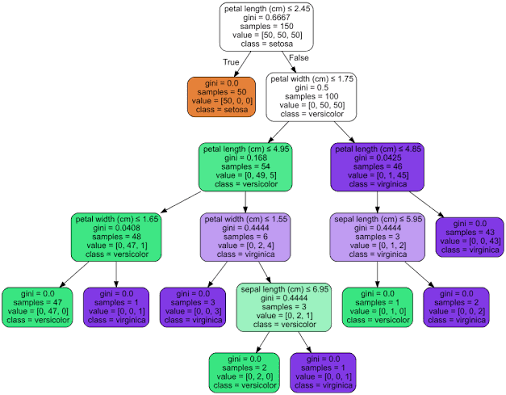>

> *A decision tree learns a sequence of feature-based splits to predict the compressive strength of a concrete mixture.*

In [14]:
# Import the Decision Tree model for regression.
from sklearn.tree import DecisionTreeRegressor

# Create a Decision Tree Regressor.
# random_state makes the result reproducible.
tree_model = DecisionTreeRegressor(
    random_state=42
)

# Train the decision tree using the training data only.
tree_model.fit(
    X_train,  # Concrete mixture features used for learning.
    y_train   # Known compressive strengths used as the target.
)

# Generate predictions for the unseen test data.
y_pred_tree = tree_model.predict(
    X_test    # Features from the holdout test set.
)

# Display a few predictions so we can see what the model produced.
print("First 5 predictions:")
print(y_pred_tree[:5])

First 5 predictions:
[19.01 22.35 17.96 56.1  44.09]


## Evaluate the Decision Tree

A model can make predictions, but we need to know how close those predictions are to the actual concrete strengths.

We will use the same three regression metrics:

- **MAE:** average prediction error in MPa.
- **RMSE:** gives more penalty to large prediction errors.
- **R²:** measures how much variation in strength the model explains.

Importantly, we evaluate using the **test set**, which the tree did not see during training.

In [15]:
# Calculate the average absolute prediction error in MPa.
tree_mae = mean_absolute_error(
    y_test,       # Actual strengths from the unseen test set.
    y_pred_tree   # Strength predictions made by the decision tree.
)

# Calculate the mean squared error.
tree_mse = mean_squared_error(
    y_test,       # Actual strengths from the unseen test set.
    y_pred_tree   # Strength predictions made by the decision tree.
)

# Take the square root to obtain RMSE in MPa.
tree_rmse = np.sqrt(tree_mse)

# Calculate R² to measure how much variation the model explains.
tree_r2 = r2_score(
    y_test,       # Actual strengths from the unseen test set.
    y_pred_tree   # Strength predictions made by the decision tree.
)

# Display the model performance.
print(f"Decision Tree MAE:  {tree_mae:.2f} MPa")
print(f"Decision Tree RMSE: {tree_rmse:.2f} MPa")
print(f"Decision Tree R²:   {tree_r2:.3f}")

Decision Tree MAE:  3.80 MPa
Decision Tree RMSE: 5.94 MPa
Decision Tree R²:   0.882


## Step 6 — Random Forest Regression

A single decision tree can work well, but it can also be sensitive to the particular data it sees.

A **Random Forest** combines many decision trees and averages their predictions.

The idea is simple:

> Instead of relying on one tree, let many different trees make predictions and combine them.

We will train a Random Forest using the same training data and evaluate it on the same test set. This lets us make a fair comparison with our Decision Tree.

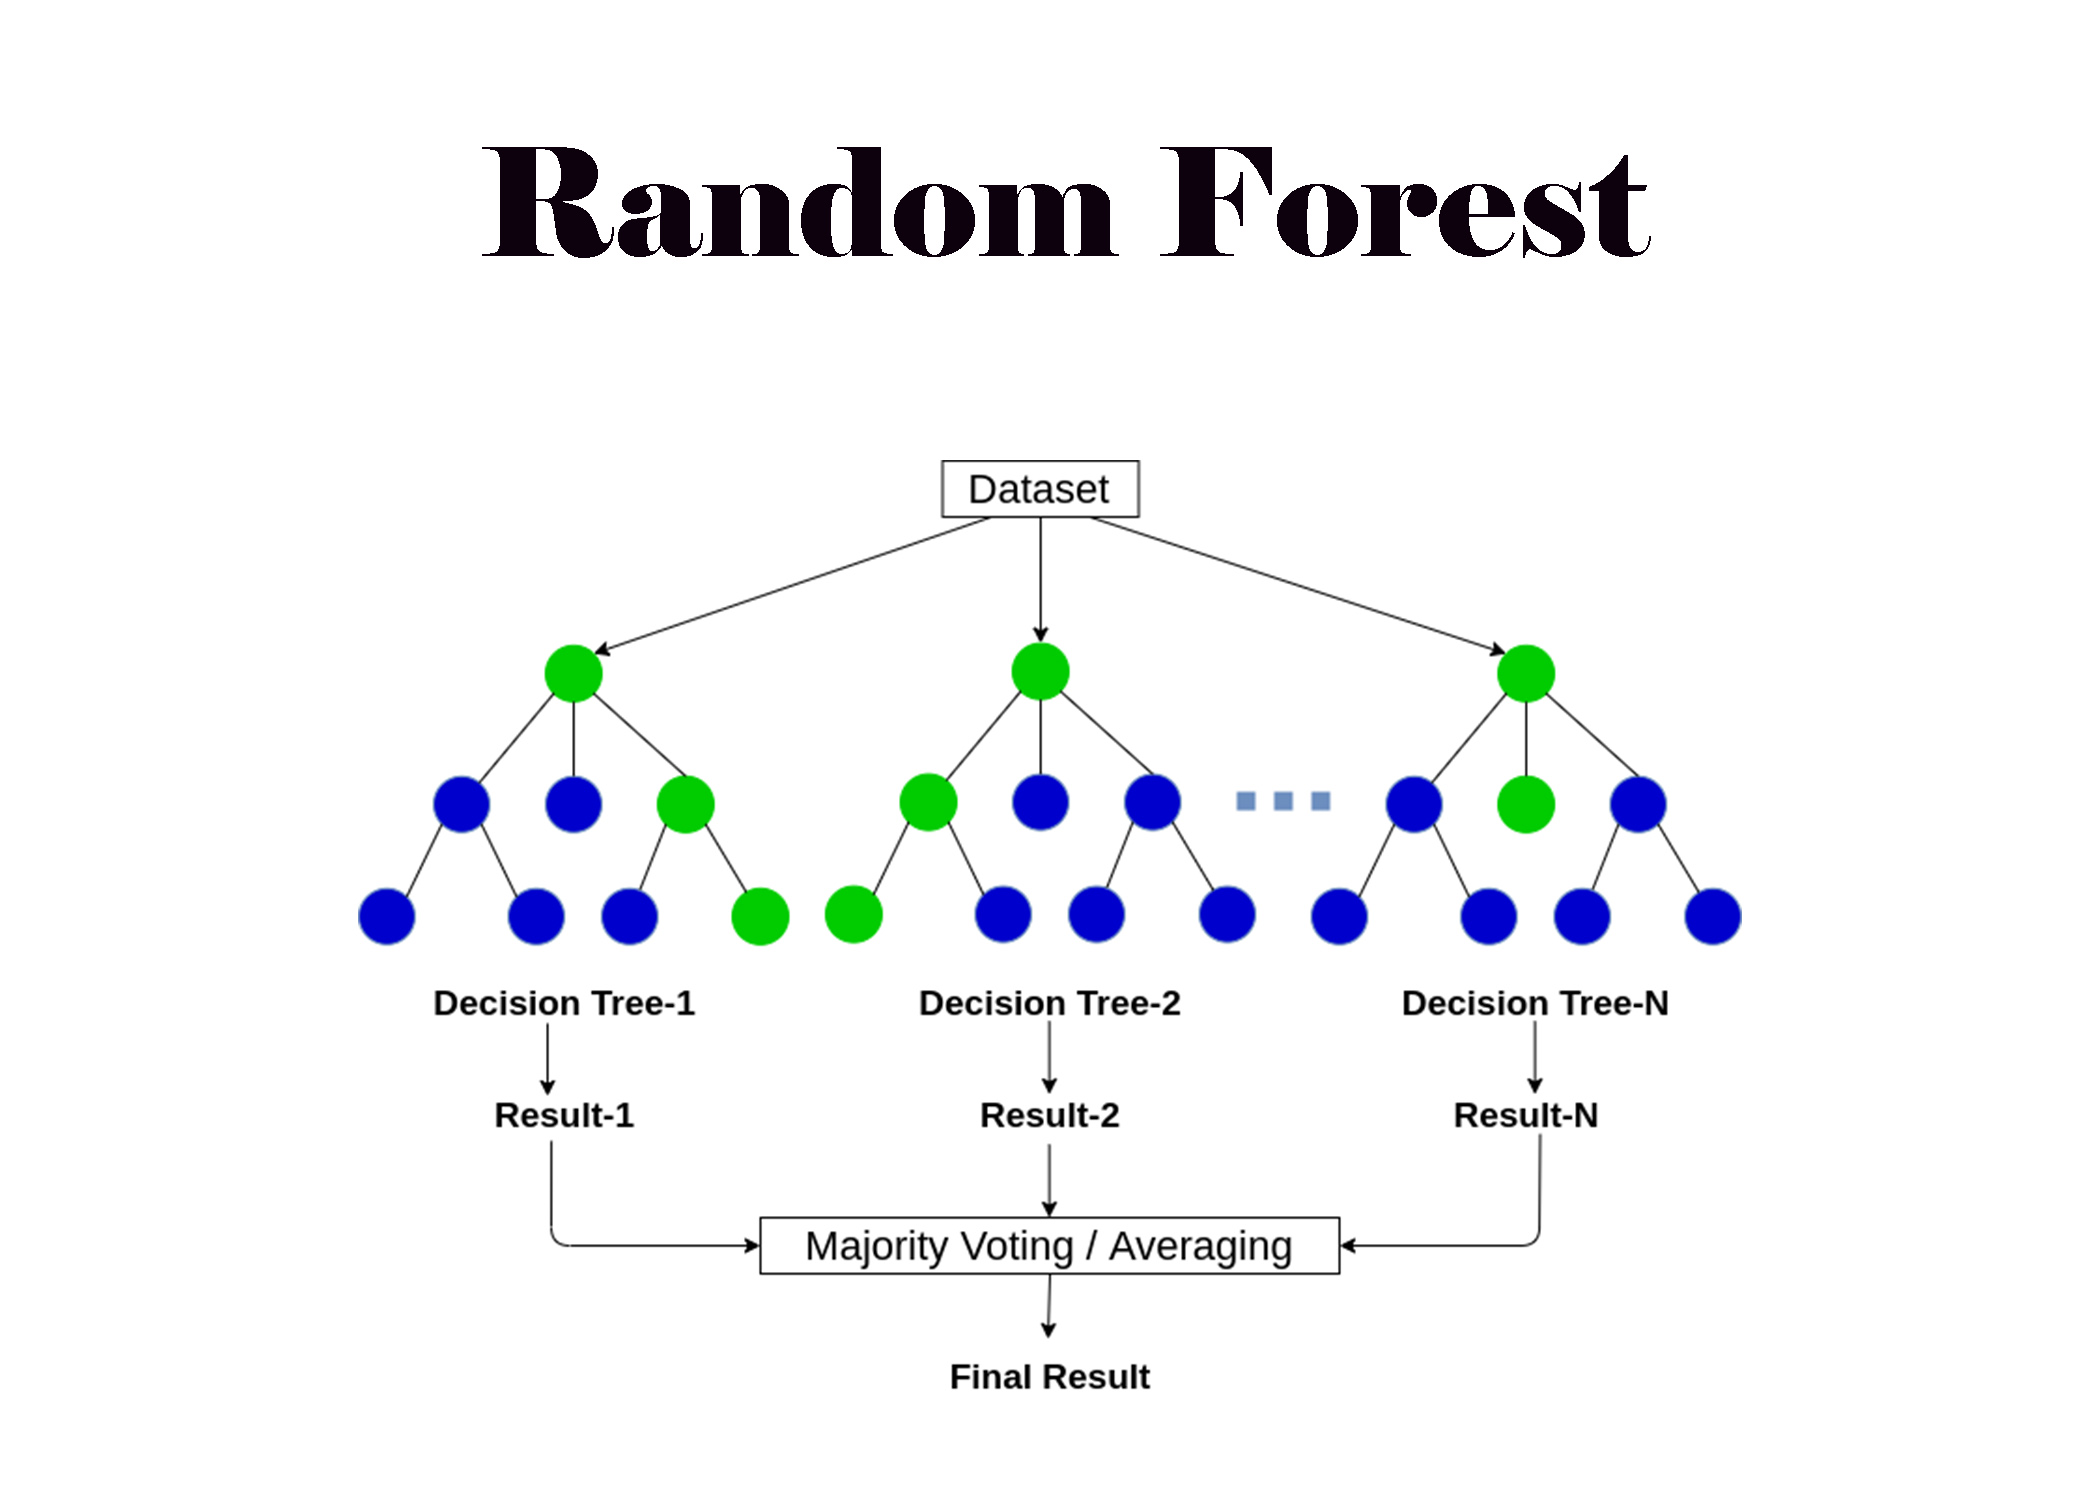

In [16]:
# Import the Random Forest model for regression.
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest containing 100 decision trees.
# random_state makes the results reproducible.
forest_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest.
    random_state=42    # Fixed seed for reproducibility.
)

# Train all trees using the training data.
forest_model.fit(
    X_train,  # Concrete mixture features.
    y_train   # Known compressive strengths.
)

# Use the trained forest to predict strength for the unseen test data.
y_pred_forest = forest_model.predict(
    X_test  # Features from the holdout test set.
)

# Display the first five predictions from the Random Forest.
print("First 5 predictions:")
print(y_pred_forest[:5])

First 5 predictions:
[21.0514     26.125      25.5738     33.51071333 46.3197    ]


## Evaluate the Random Forest

We will now evaluate the Random Forest on the same unseen test set.

Using the same evaluation metrics allows us to compare the Random Forest directly with our Decision Tree.

In [17]:
# Calculate the average absolute prediction error in MPa.
forest_mae = mean_absolute_error(
    y_test,          # Actual concrete strengths from the test set.
    y_pred_forest   # Strength predictions from the Random Forest.
)

# Calculate the mean squared error.
forest_mse = mean_squared_error(
    y_test,          # Actual concrete strengths from the test set.
    y_pred_forest   # Strength predictions from the Random Forest.
)

# Take the square root of MSE to obtain RMSE in MPa.
forest_rmse = np.sqrt(forest_mse)

# Calculate R² to measure the variation explained by the model.
forest_r2 = r2_score(
    y_test,          # Actual concrete strengths from the test set.
    y_pred_forest   # Strength predictions from the Random Forest.
)

# Display the Random Forest performance.
print(f"Random Forest MAE:  {forest_mae:.2f} MPa")
print(f"Random Forest RMSE: {forest_rmse:.2f} MPa")
print(f"Random Forest R²:   {forest_r2:.3f}")

Random Forest MAE:  3.48 MPa
Random Forest RMSE: 5.25 MPa
Random Forest R²:   0.908


## Compare the Models

We have now trained two candidate models:

- Decision Tree
- Random Forest

Before moving toward deployment, we compare their performance on the same test set.

Our goal is not simply to choose the most complicated model. We want to select the model that provides the best predictive performance for this problem.

In [18]:
# Store the performance of each model in a small comparison table.
model_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "MAE (MPa)": [
        tree_mae,
        forest_mae
    ],
    "RMSE (MPa)": [
        tree_rmse,
        forest_rmse
    ],
    "R²": [
        tree_r2,
        forest_r2
    ]
})

# Display the models from best to worst according to RMSE.
model_results.sort_values(
    by="RMSE (MPa)",      # Use RMSE as our primary comparison metric.
    ascending=True        # Lower RMSE means smaller prediction errors.
).reset_index(drop=True)

,Model,MAE (MPa),RMSE (MPa),R²
0,Random Forest,3.478606,5.250893,0.907578
1,Decision Tree,3.800473,5.940216,0.881719


## Step 7 — From Notebook to ML Pipeline

We have trained and evaluated our models. Now we move from **model development** toward a more realistic ML workflow.

In an industry setting, we would not want to manually repeat every notebook step whenever a new concrete mixture needs a prediction.

Instead, we organize the workflow so that:

**raw data → preprocessing → trained model → prediction**

This is the beginning of turning our analysis into a reusable ML pipeline.

## Step 8 — Build an ML Pipeline

In practice, we want the same preprocessing steps to happen every time the model is used.

A **pipeline** connects those steps together:

**Input data → preprocessing → model → prediction**

Our data is already numeric, and tree-based models do not require feature scaling. However, we can still include a simple **missing-value step** so that the workflow is more robust if a future dataset contains missing measurements.

The important idea is that preprocessing and the model are now treated as **one reusable object**.

In [19]:
# Import the tools needed to build the ML pipeline.
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Create a pipeline that connects preprocessing and the Random Forest model.
rf_pipeline = Pipeline(
    steps=[
        # Replace any future missing feature values with the training median.
        ("imputer", SimpleImputer(strategy="median")),

        # Use our selected Random Forest model as the final prediction step.
        ("model", RandomForestRegressor(
            n_estimators=100,   # Train 100 decision trees.
            random_state=42     # Keep the results reproducible.
        ))
    ]
)

# Train the complete pipeline using the training data.
rf_pipeline.fit(
    X_train,  # Training features.
    y_train   # Training target.
)

# Use the complete pipeline to generate predictions for the test data.
y_pred_pipeline = rf_pipeline.predict(
    X_test  # Unseen test features.
)

# Confirm that the pipeline can produce predictions.
print("First 5 pipeline predictions:")
print(y_pred_pipeline[:5])

First 5 pipeline predictions:
[21.0514     26.125      25.5738     33.51071333 46.3197    ]


## Evaluate the Complete Pipeline

The pipeline should give us the same predictive performance as the Random Forest we trained earlier.

This confirms that we have successfully connected our preprocessing and model into one reusable workflow.

In [20]:
# Calculate the MAE of the complete pipeline.
pipeline_mae = mean_absolute_error(
    y_test,              # Actual compressive strengths from the test set.
    y_pred_pipeline      # Predictions produced by the complete pipeline.
)

# Calculate the mean squared error of the pipeline.
pipeline_mse = mean_squared_error(
    y_test,              # Actual compressive strengths from the test set.
    y_pred_pipeline      # Predictions produced by the complete pipeline.
)

# Take the square root of MSE to obtain RMSE in MPa.
pipeline_rmse = np.sqrt(pipeline_mse)

# Calculate R² for the complete pipeline.
pipeline_r2 = r2_score(
    y_test,              # Actual compressive strengths from the test set.
    y_pred_pipeline      # Predictions produced by the complete pipeline.
)

# Display the final pipeline performance.
print(f"Pipeline MAE:  {pipeline_mae:.2f} MPa")
print(f"Pipeline RMSE: {pipeline_rmse:.2f} MPa")
print(f"Pipeline R²:   {pipeline_r2:.3f}")

Pipeline MAE:  3.48 MPa
Pipeline RMSE: 5.25 MPa
Pipeline R²:   0.908


## Step 9 — Save the Trained Pipeline

In an industry workflow, we do not want to retrain the model every time a new prediction is needed.

Instead, we save the trained pipeline as a **model artifact**.

The artifact contains both:

- the preprocessing steps, and
- the trained Random Forest.

Later, another application can load this artifact and use it to make predictions on new concrete mixtures.

In [21]:
# Import joblib, which is commonly used to save scikit-learn models.
import joblib

# Define the filename for our trained ML pipeline.
MODEL_PATH = "concrete_strength_pipeline.joblib"

# Save the complete pipeline to disk.
# This saves both the preprocessing step and the trained Random Forest.
joblib.dump(
    rf_pipeline,  # The trained pipeline we want to save.
    MODEL_PATH   # The file where the pipeline will be stored.
)

# Confirm that the model artifact was created.
print(f"Model pipeline saved to: {MODEL_PATH}")

Model pipeline saved to: concrete_strength_pipeline.joblib


## Step 10 — Load the Model for Inference

Imagine it is a few weeks later.

The model has already been trained and saved. A civil engineering team now has a **new concrete mixture** and wants a strength prediction.

We do not retrain the model.

Instead, we load the saved model artifact and use it to make a prediction on the new mixture.

This is the basic idea of **inference**: using a trained model to make predictions on new, unseen data.

In [22]:
# Load the joblib library so we can restore the saved pipeline.
import joblib

# Load the trained pipeline from disk.
loaded_pipeline = joblib.load(
    MODEL_PATH  # Path to the saved model artifact.
)

# Confirm that the model was loaded successfully.
print("Model loaded successfully.")

Model loaded successfully.


### A New Concrete Mixture

Suppose a new concrete mixture has been proposed by the engineering team.

We provide the same eight input variables that were available during training:

- cement
- slag
- fly ash
- water
- superplasticizer
- coarse aggregate
- fine aggregate
- age

The model will return the predicted compressive strength in MPa.

In [23]:
# Define the measurements for one new concrete mixture.
# The column names must match the features used during training.
new_mix = pd.DataFrame({
    "cement": [350.0],              # Cement content in kg/m³.
    "slag": [100.0],                # Blast furnace slag in kg/m³.
    "fly_ash": [50.0],              # Fly ash content in kg/m³.
    "water": [180.0],               # Water content in kg/m³.
    "superplasticizer": [8.0],      # Superplasticizer content in kg/m³.
    "coarse_aggregate": [1000.0],   # Coarse aggregate in kg/m³.
    "fine_aggregate": [750.0],      # Fine aggregate in kg/m³.
    "age_days": [28]                # Age of the concrete specimen in days.
})

# Use the loaded pipeline to predict compressive strength.
predicted_strength = loaded_pipeline.predict(
    new_mix  # New mixture provided by the engineering team.
)

# Display the predicted strength.
print(f"Predicted compressive strength: {predicted_strength[0]:.2f} MPa")

Predicted compressive strength: 48.10 MPa


## Step 11 — From Prediction to Engineering Decision

The model predicts a compressive strength of **48.10 MPa** for this proposed mixture.

The important point is that an ML model does not make the engineering decision for us.

Instead, it provides a prediction that can support engineering decisions, screening, and further testing.

In a real workflow, this prediction would be considered alongside design requirements, safety factors, standards, cost, constructability, and laboratory validation.

In [24]:
# Extract the predicted strength as a single numerical value.
predicted_mpa = predicted_strength[0]

# Define an example screening threshold for this demonstration.
# This is NOT a concrete design code requirement.
screening_threshold = 40.0  # MPa.

# Compare the model prediction with the screening threshold.
if predicted_mpa >= screening_threshold:
    decision = "Passes the preliminary screening threshold."
else:
    decision = "Does not pass the preliminary screening threshold."

# Report the prediction and the preliminary screening result.
print(f"Predicted strength: {predicted_mpa:.2f} MPa")
print(f"Preliminary screening: {decision}")

Predicted strength: 48.10 MPa
Preliminary screening: Passes the preliminary screening threshold.


## Step 12 — What Happens After Deployment?

We have followed a simplified version of an industry ML workflow:

**Data → Cleaning → Exploration → Train/Test Split → Baseline → Model Training → Evaluation → Pipeline → Model Artifact → Inference → Engineering Screening**

In a real ML system, the work would continue.

New laboratory results could be used to monitor model performance, detect changes in the data, and decide when the model should be retrained. Models would also be versioned and monitored after deployment.

The key lesson is that **building an ML model is only one part of an ML system**. A professional workflow also needs a reliable way to prepare data, reproduce predictions, evaluate performance, and use the model on new data.

# ---------------------- OPTIONAL -----------------------

In [25]:
# Import pandas so that user inputs can be converted into a DataFrame.
import pandas as pd

# Import ipywidgets to create interactive controls inside the notebook.
import ipywidgets as widgets

# Import display so that we can show the dashboard in the notebook.
from IPython.display import display


# -----------------------------
# 1. Create the input controls
# -----------------------------

# Create an input box for cement content.
cement_input = widgets.FloatText(
    value=350.0,                         # Starting example value in kg/m³.
    description="Cement:",              # Label shown beside the input.
    style={"description_width": "150px"} # Give the label enough space.
)

# Create an input box for blast furnace slag.
slag_input = widgets.FloatText(
    value=100.0,                        # Starting example value in kg/m³.
    description="Slag:",               # Label shown beside the input.
    style={"description_width": "150px"} # Give the label enough space.
)

# Create an input box for fly ash.
fly_ash_input = widgets.FloatText(
    value=50.0,                         # Starting example value in kg/m³.
    description="Fly ash:",             # Label shown beside the input.
    style={"description_width": "150px"} # Give the label enough space.
)

# Create an input box for water.
water_input = widgets.FloatText(
    value=180.0,                        # Starting example value in kg/m³.
    description="Water:",               # Label shown beside the input.
    style={"description_width": "150px"} # Give the label enough space.
)

# Create an input box for superplasticizer.
superplasticizer_input = widgets.FloatText(
    value=8.0,                          # Starting example value in kg/m³.
    description="Superplasticizer:",    # Label shown beside the input.
    style={"description_width": "150px"} # Give the label enough space.
)

# Create an input box for coarse aggregate.
coarse_aggregate_input = widgets.FloatText(
    value=1000.0,                       # Starting example value in kg/m³.
    description="Coarse aggregate:",    # Label shown beside the input.
    style={"description_width": "150px"} # Give the label enough space.
)

# Create an input box for fine aggregate.
fine_aggregate_input = widgets.FloatText(
    value=750.0,                        # Starting example value in kg/m³.
    description="Fine aggregate:",      # Label shown beside the input.
    style={"description_width": "150px"} # Give the label enough space.
)

# Create an input box for concrete age.
age_input = widgets.IntText(
    value=28,                           # Starting example age in days.
    description="Age (days):",          # Label shown beside the input.
    style={"description_width": "150px"} # Give the label enough space.
)


# -----------------------------
# 2. Create the dashboard buttons
# -----------------------------

# Create a button that loads a predefined example mixture.
example_button = widgets.Button(
    description="Load Example Mixture", # Text displayed on the button.
    button_style="info"                  # Give the button a dashboard-style appearance.
)

# Create a button that sends the entered mixture to the ML model.
predict_button = widgets.Button(
    description="Predict Strength",      # Text displayed on the button.
    button_style="success"               # Highlight the main prediction action.
)


# -----------------------------
# 3. Create an output area
# -----------------------------

# Create an output area where prediction results will appear.
output = widgets.Output()


# -----------------------------
# 4. Define the example mixture
# -----------------------------

# Store one example mixture that students can load automatically.
example_values = {
    "cement": 350.0,              # Cement content in kg/m³.
    "slag": 100.0,                # Blast furnace slag in kg/m³.
    "fly_ash": 50.0,              # Fly ash content in kg/m³.
    "water": 180.0,               # Water content in kg/m³.
    "superplasticizer": 8.0,      # Superplasticizer content in kg/m³.
    "coarse_aggregate": 1000.0,   # Coarse aggregate content in kg/m³.
    "fine_aggregate": 750.0,      # Fine aggregate content in kg/m³.
    "age_days": 28                 # Concrete age in days.
}


# -----------------------------
# 5. Define the example button
# -----------------------------

# Define what should happen when the example button is clicked.
def load_example(button):

    # Put the example cement value into the cement input box.
    cement_input.value = example_values["cement"]

    # Put the example slag value into the slag input box.
    slag_input.value = example_values["slag"]

    # Put the example fly ash value into the fly ash input box.
    fly_ash_input.value = example_values["fly_ash"]

    # Put the example water value into the water input box.
    water_input.value = example_values["water"]

    # Put the example superplasticizer value into its input box.
    superplasticizer_input.value = example_values["superplasticizer"]

    # Put the example coarse aggregate value into its input box.
    coarse_aggregate_input.value = example_values["coarse_aggregate"]

    # Put the example fine aggregate value into its input box.
    fine_aggregate_input.value = example_values["fine_aggregate"]

    # Put the example age into the age input box.
    age_input.value = example_values["age_days"]


# Connect the example button to the function above.
example_button.on_click(load_example)


# -----------------------------
# 6. Define the prediction button
# -----------------------------

# Define what should happen when the prediction button is clicked.
def make_prediction(button):

    # Clear any previous prediction displayed in the output area.
    output.clear_output()

    # Collect the values entered by the user into one dictionary.
    input_values = {
        "cement": cement_input.value,                         # Cement input.
        "slag": slag_input.value,                             # Slag input.
        "fly_ash": fly_ash_input.value,                       # Fly ash input.
        "water": water_input.value,                           # Water input.
        "superplasticizer": superplasticizer_input.value,     # Superplasticizer input.
        "coarse_aggregate": coarse_aggregate_input.value,     # Coarse aggregate input.
        "fine_aggregate": fine_aggregate_input.value,         # Fine aggregate input.
        "age_days": age_input.value                           # Concrete age input.
    }

    # Convert the dictionary into a one-row DataFrame.
    new_concrete = pd.DataFrame([input_values])

    # Use the saved ML pipeline to predict compressive strength.
    prediction = loaded_pipeline.predict(new_concrete)

    # Extract the predicted strength from the one-element prediction array.
    predicted_mpa = prediction[0]

    # Display the result in the dashboard output area.
    with output:

        # Print a separator to make the result visually clear.
        print("=" * 45)

        # Display the predicted compressive strength.
        print(f"Predicted compressive strength: {predicted_mpa:.2f} MPa")

        # Print another separator below the result.
        print("=" * 45)

        # Remind the user that this is a model prediction.
        print("This is an ML prediction, not a laboratory test.")


# Connect the prediction button to the prediction function.
predict_button.on_click(make_prediction)


# -----------------------------
# 7. Arrange the dashboard
# -----------------------------

# Put all input controls into a vertical layout.
inputs = widgets.VBox([
    cement_input,                  # Cement input.
    slag_input,                    # Slag input.
    fly_ash_input,                 # Fly ash input.
    water_input,                   # Water input.
    superplasticizer_input,        # Superplasticizer input.
    coarse_aggregate_input,        # Coarse aggregate input.
    fine_aggregate_input,          # Fine aggregate input.
    age_input                      # Age input.
])

# Put the two action buttons next to each other.
buttons = widgets.HBox([
    example_button,                # Button for loading the example.
    predict_button                 # Button for running the model.
])

# Create a title for the dashboard.
title = widgets.HTML(
    "<h3>Concrete Compressive Strength Predictor</h3>"
)

# Display the complete interactive dashboard.
display(
    title,                          # Dashboard title.
    inputs,                         # Engineering inputs.
    buttons,                        # Dashboard actions.
    output                          # Prediction result area.
)

HTML(value='<h3>Concrete Compressive Strength Predictor</h3>')

Output()